Adding the necessary libraries

In [ ]:
#!/usr/bin/env python3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

Loading video game sales data from github to a dataframe

In [2]:
url = "https://gist.githubusercontent.com/designernatan/27da044c6dc823f7ac7fe3a01f4513ed/raw/d15b5c7d7a5efb38750b16ec935fc126ec9a6e79/vgsales.csv"

videoGameData_df = pd.read_csv(url)

pd.set_option('display.width', None)
display(videoGameData_df.head(10))

#videoGameData_df.to_csv('videoGameData.csv')      #saving video game data to a csv as backup

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


Exploratory Data Analysis

Looking at video games by platform

,Platform,count
0,DS,2163
1,PS2,2161
2,PS3,1329
3,Wii,1325
4,X360,1265
5,PSP,1213
6,PS,1196
7,PC,960
8,XB,824
9,GBA,822


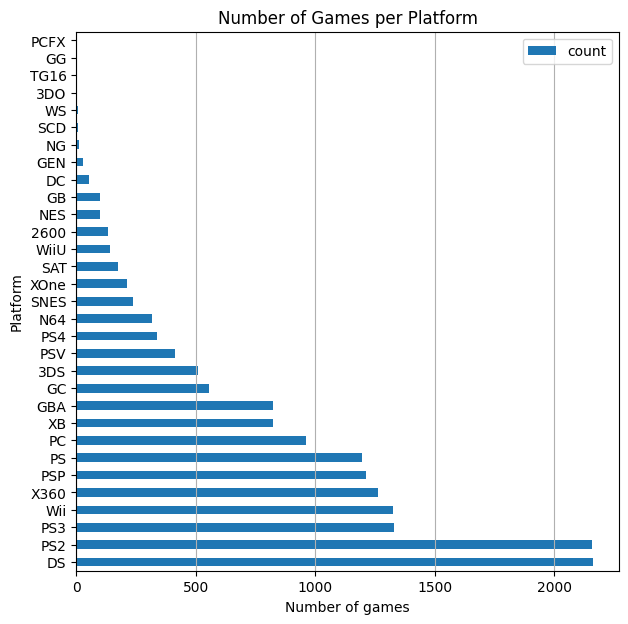

In [3]:
df = videoGameData_df['Platform'].value_counts().reset_index()
#df = df.to_frame()
display(df)
#print(df.columns.tolist())

df.plot(x='Platform', y='count', kind='barh', figsize=[7,7])
#plt.xticks(rotation=0, ha='right')
plt.xlabel(xlabel='Number of games')
plt.title('Number of Games per Platform')
plt.grid(axis='x')
plt.show()

Looking at Game genre distribution overall

In [ ]:
df = videoGameData_df['Genre'].value_counts().reset_index()
print(df)

df.plot(y='count', kind='pie', labels=df['Genre'], autopct='%1.1f%%', textprops={'fontsize': 10}, figsize=(12,8), legend=False)
plt.ylabel('')
plt.title('Game Genre Distribution')
plt.show()

Looking at the platforms with the most and least games released

In [ ]:
df = videoGameData_df['Platform'].value_counts().reset_index()

dfMost = df.head(10)
dfMost.plot(x='Platform', y='count', kind='barh')
#plt.xticks(rotation=0, ha='right')
plt.xlabel(xlabel='Number of games')
plt.title('10 Platforms with the Most Games')
plt.grid(axis='x')
plt.show()

dfLeast = df.tail(10)
dfLeast.plot(x='Platform', y='count', kind='barh')
#plt.xticks(rotation=0, ha='right')
plt.xlabel(xlabel='Number of games')
plt.title('10 Platforms with the Least Games')
plt.grid(axis='x')
plt.show()

Looking at video game genres for top 3 most popular platforms

In [ ]:
#df = videoGameData_df['Platform'].value_counts().reset_index()

df = videoGameData_df['Platform'].value_counts().reset_index()
platform1 = df['Platform'][0]   #getting name of platform with most games
platform2 = df['Platform'][1]   #getting name of platform with most games
platform3 = df['Platform'][2]   #getting name of platform with most games
print(platform1, platform2, platform3)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

df = videoGameData_df[videoGameData_df['Platform']==platform1]['Genre'].value_counts().reset_index()
ax1.pie(df['count'], labels=df['Genre'], autopct='%1.1f%%', textprops={'fontsize': 10})
ax1.set_title(platform1 + ' Game Genres')

df = videoGameData_df[videoGameData_df['Platform']==platform2]['Genre'].value_counts().reset_index()
ax2.pie(df['count'], labels=df['Genre'], autopct='%1.1f%%', textprops={'fontsize': 10})
ax2.set_title(platform2 + ' Game Genres')

df = videoGameData_df[videoGameData_df['Platform']==platform2]['Genre'].value_counts().reset_index()
ax3.pie(df['count'], labels=df['Genre'], autopct='%1.1f%%', textprops={'fontsize': 10})
ax3.set_title(platform3 + ' Game Genres')

Sales Trends per Year

In [ ]:
df = videoGameData_df.groupby('Year').sum().reset_index()
#print(df.head(10))
#print(df.dtypes)

#fig, ax = plt.subplots(figsize=(8, 5))

fig, ax = plt.subplots(figsize=(8, 5))

#ax.plot(df['Platform'], df['NA_Sales'])
ax.plot(df['Year'], df['NA_Sales'], label='NA_Sales')
ax.plot(df['Year'], df['EU_Sales'], label='EU_Sales')
ax.plot(df['Year'], df['JP_Sales'], label='JP_Sales')
ax.plot(df['Year'], df['Other_Sales'], label='Other_Sales')
ax.plot(df['Year'], df['Global_Sales'], label='Global_Sales')

ax.legend(loc='upper left')
ax.set_title('Sales over time')
ax.grid(alpha = 0.3)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Games Sold')

Money per platform bar charts

In [ ]:
df = videoGameData_df.groupby('Platform').sum().reset_index()
#display(df.head(10))

fig, ax = plt.subplots(2, 2,figsize=(16, 12))

#print(len(df['Platform']))

ax[0,0].bar(df['Platform'], df['NA_Sales'], label='NA_Sales', color='dodgerblue',)
ax[0,0].set_title('NA Sales per Platform')
ax[0,1].bar(df['Platform'], df['EU_Sales'], label='EU_Sales', color='orange')
ax[0,1].set_title('EU Sales per Platform')
ax[1,0].bar(df['Platform'], df['JP_Sales'], label='JP_Sales', color='green')
ax[1,0].set_title('JP Sales per Platform')
ax[1,1].bar(df['Platform'], df['Other_Sales'], label='Other_Sales', color='red')
ax[1,1].set_title('Other Sales per Platform')

for axs in ax.flatten():
    #axs.tick_params(axis='x', labelsize=8)
    axs.tick_params(axis='x', rotation= 90)

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(df['Platform'], df['Global_Sales'], label='Global_Sales', color='mediumpurple')
ax.set_title('Global Sales per Platform')

Money per platform grouped bar chart

In [ ]:
df = videoGameData_df.groupby('Platform').sum().reset_index()

x = np.arange(len(df['Platform']))  
width = 1/5  

fig, ax = plt.subplots(figsize=(15, 5))

ax.bar(x - 2*width, df['NA_Sales'], width, label='NA_Sales')
ax.bar(x - width, df['EU_Sales'], width, label='EU_Sales')
ax.bar(x, df['JP_Sales'], width, label='JP_Sales')
ax.bar(x + width, df['Other_Sales'], width, label='Other_Sales')
ax.bar(x + 2*width, df['Global_Sales'], width, label='Global_Sales')

ax.legend(loc='upper left')
ax.set_title('Sales per Platform')
ax.grid(alpha = 0.3)
ax.set_xlabel('Platform')
ax.set_ylabel('Number of Games Sold')
ax.set_xticks(np.arange(0, len(df['Platform']), 1))
ax.set_xticklabels(df['Platform'])
#ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

Looking at Publishers

Top 10 Publishers with most games published

In [ ]:
df = videoGameData_df['Publisher'].value_counts().reset_index()
display(df.head(10))

Top 10 Publishers with the Most Global Sales

In [ ]:
df = videoGameData_df.groupby('Publisher').sum().reset_index()

df= df.sort_values(by=['Global_Sales'], ascending=False).head(10).reset_index()
df = df[['Publisher','NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']]
display(df.head(10))


Game releases per year

In [ ]:
df = videoGameData_df['Year'].value_counts().reset_index().sort_values(by='Year', ignore_index=True)
df['Year'] = df['Year'].astype(int)
#display(df)

df.plot(x='Year', y='count', kind = 'bar', figsize=[10,5])
plt.grid()
plt.xticks(rotation=45, ha='right')
plt.xlabel(xlabel='Year')
plt.ylabel(ylabel='Number of Games')
plt.title('Number of Games Released per Year')
plt.grid(axis='x')
plt.show()


Heatmap for Number of Games per Platform and Genre

In [ ]:
df = videoGameData_df.pivot_table(values='Global_Sales',index='Genre',columns='Platform',aggfunc='sum')

display(df)

#print(df.index)

plt.figure(figsize=(10, 5))
plt.imshow(df, cmap='plasma', interpolation='nearest')
plt.xlabel(xlabel='Platform')
plt.ylabel(ylabel='Genre')
plt.xticks(ticks=range(len(df.columns)), labels=df.columns, rotation = 45)
plt.yticks(ticks=range(len(df.index)), labels=df.index)
plt.colorbar(shrink=0.7) 
plt.title('Heatmap of number of games by Platform and Genre')
plt.show()

Sum of global sales by publisher, mean, and count of number of games.

In [ ]:
df = videoGameData_df.groupby('Publisher')['Global_Sales'].agg(['sum', 'mean', 'count']).sort_values(by='count', ascending=False).reset_index()
print("Top 10 Publishers when sorted by number of games (count)")
display(df.head(10))

df = videoGameData_df.groupby('Publisher')['Global_Sales'].agg(['sum', 'mean', 'count']).sort_values(by='mean', ascending=False).reset_index()
print("Top 10 Publishers when sorted by mean")
display(df.head(10))

Sum of global sales by platform, mean, and count of number of games.

In [ ]:
df = videoGameData_df.groupby('Platform')['Global_Sales'].agg(['sum', 'mean', 'count']).sort_values(by='count', ascending=False).reset_index()
print("Platforms sorted by number of games (count)")
display(df)

df = videoGameData_df.groupby('Platform')['Global_Sales'].agg(['sum', 'mean', 'count']).sort_values(by='mean', ascending=False).reset_index()
print("Platform sorted by mean")
display(df.head(20))

Correlation matrix for global sales

In [ ]:
df = videoGameData_df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].corr()

display(df)

Genre Popularity over the Years

In [ ]:
df = videoGameData_df.groupby('Year')['Genre'].value_counts().unstack().reset_index()
df['Year'] = df["Year"].astype(int)
df= df.reset_index(drop=True).set_index('Year')
#display(df)

df.plot(kind='barh', stacked=True, figsize=[10,8])
plt.legend(loc="lower right", ncol=2)
plt.xlabel('Number of games')
plt.ylabel('Year')
plt.title('Genre Popularity over time')
plt.grid(axis='x')
plt.show()


df = videoGameData_df.groupby('Year')['Genre'].value_counts().unstack().reset_index()
df['Year'] = df["Year"].astype(int)
#display(df)

fig, ax = plt.subplots(figsize=(10, 5))
for columnName in df.columns:
    if columnName != 'Year': 
        #print(columnName)
        ax.plot(df['Year'], df[columnName], label=columnName)

ax.legend(loc='upper left')
ax.set_title('Genre popularity over time')
ax.grid(alpha = 0.3)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Games in that Genre')


Platform by publisher

In [ ]:
df = videoGameData_df.groupby('Platform')['Publisher'].value_counts().unstack()
#display(df)

df.plot(kind='barh', stacked=True, figsize=[10,8], legend=False)
#plt.legend(loc="upper right", ncol=5, fontsize='small')
plt.xlabel('Number of games')
plt.ylabel('Publisher')
plt.title('Publisher per platform')
plt.grid(axis='x')
plt.show()

In [ ]:
df = videoGameData_df['Platform'].value_counts(normalize=True)*100     #getting the percentages
df = df.reset_index()
#print(df)

indexCounter =0
for number in df['proportion']:
    if number < 2:
        df.at[indexCounter,'Platform'] = 'Other'
        indexCounter = indexCounter+1

    else:
        indexCounter = indexCounter+1

df = df.groupby('Platform').sum().reset_index()
df = df.sort_values(by='proportion', ascending=False)
#print(df)

df.plot(y='proportion', kind='pie', labels=df['Platform'], autopct='%1.1f%%', textprops={'fontsize': 10}, figsize=(12,8), legend=False)
plt.ylabel('')
plt.title('Distribution of Game Platforms')
plt.show()